# Q3

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout


## Dataset Loading

1. Date  
   - The trading date (UTC)

2. Open  
   - The price of the first trade of BTC-USD on that date.  

3. High  
   - The highest trade price of BTC-USD during the date.  

4. Low  
   - The lowest trade price of BTC-USD during the date.  

5. Close  
   - The price of the last trade of BTC-USD on that date (or interval).    

6. Volume  
   - The total number of BTC units traded during that date.

In [32]:
df = pd.read_csv('BTC-USD.csv', parse_dates=['Date'], index_col='Date')
df.drop(columns=['Id'], inplace=True)
print(df.head())


                  Open        High         Low       Close    Volume
Date                                                                
2014-09-17  465.864014  468.174011  452.421997  457.334015  21056800
2014-09-18  456.859985  456.859985  413.104004  424.440002  34483200
2014-09-19  424.102997  427.834991  384.532013  394.795990  37919700
2014-09-20  394.673004  423.295990  389.882996  408.903992  36863600
2014-09-21  408.084991  412.425995  393.181000  398.821014  26580100


## Exploratory Data Analysis (EDA) on OHLCV

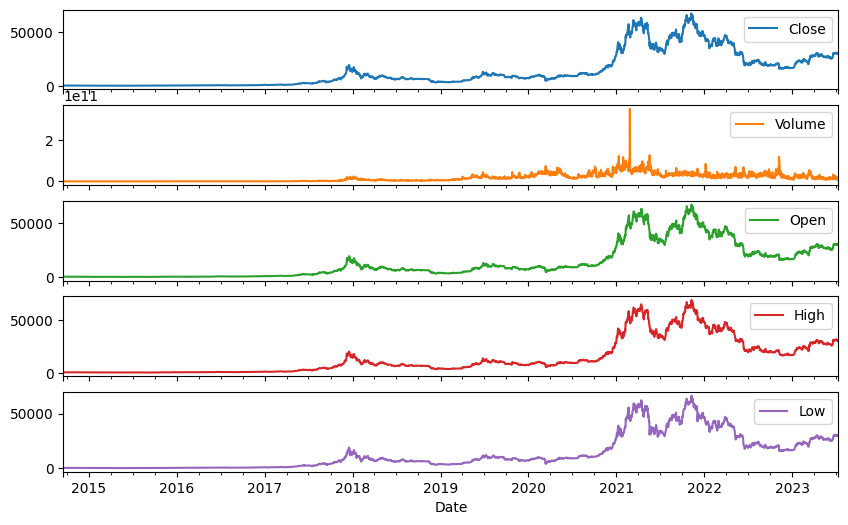

               Open          High           Low         Close        Volume
count   3222.000000   3222.000000   3222.000000   3222.000000  3.222000e+03
mean   13633.555524  13966.498897  13269.790975  13641.491658  1.657062e+10
std    16016.593310  16417.423832  15559.562019  16014.439000  1.950701e+10
min      176.897003    211.731003    171.509995    178.102997  5.914570e+06
25%      757.838730    772.024277    745.732499    759.970260  1.300485e+08
50%     7664.044434   7867.845215   7499.634766   7679.053711  1.017502e+10
75%    20210.792481  20660.277832  19811.524414  20238.632813  2.746342e+10
max    67549.734375  68789.625000  66382.062500  67566.828125  3.509679e+11
            Open      High       Low     Close    Volume
Open    1.000000  0.999502  0.999102  0.998791  0.704183
High    0.999502  1.000000  0.998987  0.999460  0.708575
Low     0.999102  0.998987  1.000000  0.999365  0.695505
Close   0.998791  0.999460  0.999365  1.000000  0.702862
Volume  0.704183  0.708575  0.6

In [33]:
df[['Close', 'Volume', 'Open', 'High', 'Low']].plot(subplots=True, figsize=(10,6))
plt.show()
print(df.describe())
print( df.corr())


## Data Processing

- Why do we use both a Validation Set and a Test Set?

We use the validation set to tune the model, like changing layers or learning rate.
We use the test set only at the end, to check the final performance.
If we only use the test set, we might accidentally change the model to fit it too much.
So, having both sets helps us avoid overfitting.


In [34]:
df = df.ffill()

scaler = MinMaxScaler()
data = scaler.fit_transform(df[['Open','High','Low','Close','Volume']])

df['Target'] = df['Close'].pct_change().shift(-1)
df = df.dropna()
targets = df['Target'].values.reshape(-1,1)
t_scaler = MinMaxScaler()
targets_scaled = t_scaler.fit_transform(targets)

def make_sequences(X, y, lookback=30):
    Xs, ys = [], []
    for i in range(len(X)-lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])
    return np.array(Xs), np.array(ys)

LOOKBACK = 30
X, y = make_sequences(data[:len(targets_scaled)], targets_scaled, LOOKBACK)

n = len(X)
train_end = int(n*0.7)
val_end   = int(n*0.85)
X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]


## Model Architecture

- What is the difference between RNN and LSTM?

Both RNN and LSTM are used for time series.
RNN is simple and faster, but forgets long-term data.
LSTM is more advanced. It can remember things for a longer time.
So, LSTM is better for complex or long patterns.

- Which model was better in this project: RNN or LSTM? Why?

In my project, LSTM gave better results (lower error).
This is because LSTM can learn long-term patterns better than RNN.
Bitcoin price changes slowly over many days, so LSTM is better for this.



In [ ]:
def build_rnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),                   
        SimpleRNN(32, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),                  
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

## Model Training

In [36]:
input_shape = (LOOKBACK, X.shape[2])
rnn = build_rnn(input_shape)
history_rnn = rnn.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),
    epochs=20, batch_size=32
)

lstm = build_lstm(input_shape)
history_lstm = lstm.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),
    epochs=20, batch_size=32
)


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1721 - val_loss: 0.1247
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0177 - val_loss: 0.2299
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0127 - val_loss: 0.1569
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0109 - val_loss: 0.1427
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0098 - val_loss: 0.1097
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083 - val_loss: 0.1206
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084 - val_loss: 0.0715
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - val_loss: 0.0455
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - val_loss: 0.0692
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0774
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 0.0583
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0070 - val_lo

## Evaluation and Visualization

- What do these metrics mean?

    - MSE (Mean Squared Error):
        Average of squared errors. If it is big, model is not good.
    - RMSE (Root MSE):
        Just the square root of MSE. Easier to understand because it has same unit as target.
    - MAE (Mean Absolute Error):
        Average of absolute errors. Shows how much model is off, on average.
    - MAPE (Mean Absolute Percentage Error):
        Like MAE, but in percent. It tells us how big the error is compared to the real value.
    - CE (Cumulative Error):
        Total error. If it is positive, model predicts too high. If negative, predicts too low.


- What do we learn from the error plot?

The error plot shows where the model makes big or small mistakes.
If error suddenly goes up, maybe the market changed a lot on that day.
By looking at the error plot, we can improve the model later.

In [37]:
def evaluate(model, X, y_true):
    y_pred = model.predict(X)
    y_pred_inv = t_scaler.inverse_transform(y_pred)
    y_true_inv = t_scaler.inverse_transform(y_true)
    mse = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100
    ce = np.sum(y_pred_inv - y_true_inv)
    return dict(MSE=mse, RMSE=rmse, MAE=mae, MAPE=mape, CE=ce), y_pred_inv, y_true_inv

metrics_rnn, y_pred_rnn, y_true = evaluate(rnn, X_test, y_test)
metrics_lstm, y_pred_lstm, _ = evaluate(lstm, X_test, y_test)

print("RNN metrics:", metrics_rnn)
print("LSTM metrics:", metrics_lstm)



15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
RNN metrics: {'MSE': 0.0016841069288843842, 'RMSE': np.float64(0.04103787188542291), 'MAE': 0.03168536038154101, 'MAPE': np.float64(743.3948577165497), 'CE': np.float64(-11.412470119501668)}
LSTM metrics: {'MSE': 0.0008922552369442366, 'RMSE': np.float64(0.02987064172300683), 'MAE': 0.020489760613313337, 'MAPE': np.float64(169.56917211175892), 'CE': np.float64(-1.7399611356197426)}


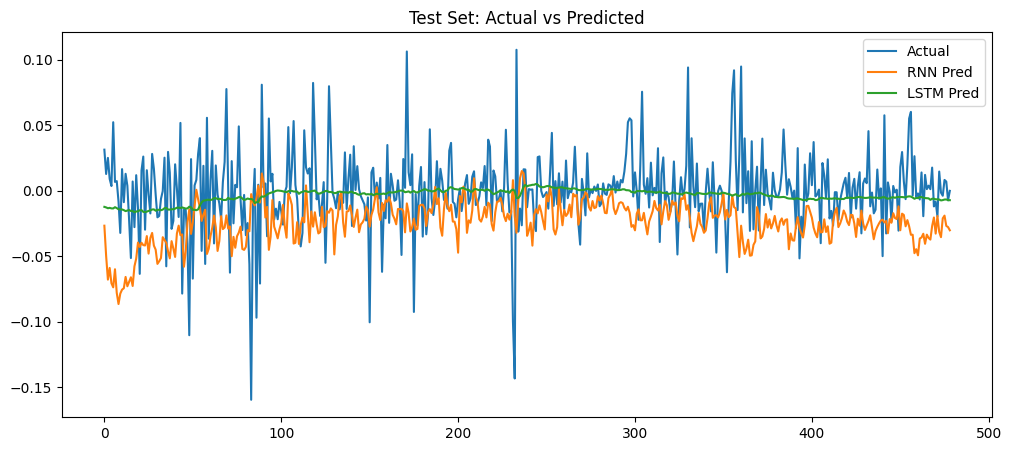

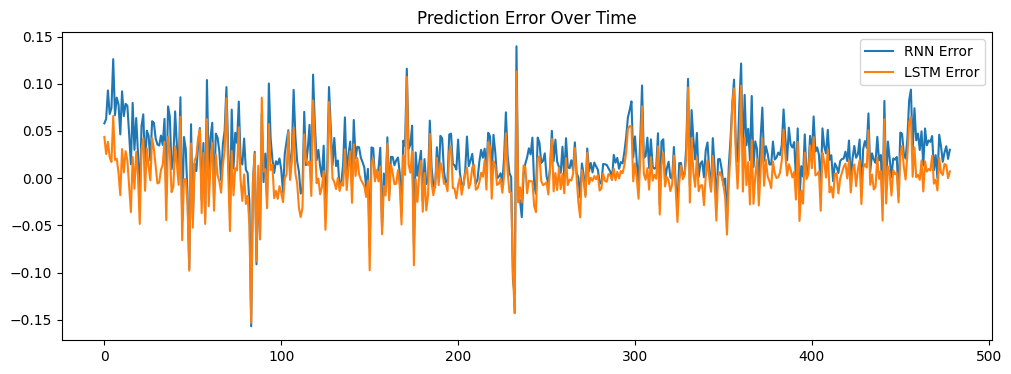

In [38]:
plt.figure(figsize=(12,5))
plt.plot(y_true, label='Actual')
plt.plot(y_pred_rnn, label='RNN Pred')
plt.plot(y_pred_lstm, label='LSTM Pred')
plt.legend(); plt.title('Test Set: Actual vs Predicted')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(y_true - y_pred_rnn, label='RNN Error')
plt.plot(y_true - y_pred_lstm, label='LSTM Error')
plt.legend(); plt.title('Prediction Error Over Time')
plt.show()

# Bonus Questions

### 1. Under what conditions is MLP equivalent to Logistic Regression?

An MLP (Multi-Layer Perceptron) becomes the same as Logistic Regression when:It has only one layer (no hidden layers), uses a sigmoid activation function (for binary classification) and takes the original input features directly, without any transformations. In this case, the model is just a linear combination of inputs followed by a sigmoid, which is exactly what **Logistic Regression** does:

$$
\hat{y} = \sigma(w_1x_1 + w_2x_2 + \ldots + w_nx_n + b)
$$

So, when there's no hidden layer, the MLP is doing the same job as Logistic Regression.


### 2. CNN with 3 filters of size 2×2×3 on a 28×28×3 image (valid padding)

#### A. How many learnable parameters?

- Each filter has size 2×2×3 = 12 parameters.
- There are 3 filters, so total weights = 3 × 12 = 36.
- Each filter also has 1 bias, so 3 biases total.

Total parameters = 36 (weights) + 3 (biases) = 39

---

#### B. What if we use a fully connected layer instead?

In a fully connected layer, every pixel in the input image (28×28×3 = 2352 values) connects to every output neuron.

- Let's say the convolution output size is: Since filter size is 2×2 and padding is "valid", the output for 28×28 input becomes (28−2+1) = 27, so output shape = 27×27×3 = 2187 values. So, to fully connect the 2352 input values to 2187 outputs: 
- Parameters = 2352 × 2187 = 5,143,224 weights
- 2187 biases = Total ≈ 5.1 million parameters

Much more than 39! That’s why CNNs are more efficient.

---

### 3. Vanishing Gradient Problem in RNNs

#### Mathematical Idea:

In RNNs, we update weights using backpropagation through time (BPTT).
The gradient at time step t is calculated as:

$$
\frac{\partial L}{\partial W} = \sum_{k=1}^{t} \left( \prod_{i=k}^{t} \frac{\partial h_i}{\partial h_{i-1}} \right) \frac{\partial L}{\partial h_t}
$$

Each $\frac{\partial h_i}{\partial h_{i-1}}$ is often a small number (like < 1). So when we multiply many of them, the gradient becomes very small, this is the vanishing gradient problem. It means the model stops learning long-term dependencies.

---

#### Lookback Window Effect:

The lookback window is how many past time steps we give to the RNN. If lookback = small (e.g. 10): fewer multiplications vanishing gradient is less severe and If lookback = large (e.g. 100)** → more steps in the chain: gradient may vanish or explode

So Larger lookback window = higher chance of vanishing gradient, unless we use better architectures like LSTM or GRU.

